# Price forecasting with a bidirectional LSTM
**Problem:** Forecast the next closing price from the previous 99 days.
**Approach:** Min-max scale the closes, build 100-step sequences with a 95/5 train/test split, stack three bidirectional LSTM layers with dropout, train with MSE loss, then compare predicted and actual prices after inverse-scaling.
**Data:** Public Yahoo Finance history for `VTI`.
**Attribution:** adapted from the stock-prediction notebook in curiousily's [*Deep-Learning-For-Hackers*](https://github.com/curiousily/Deep-Learning-For-Hackers), which used a BTC-USD CSV. This version pulls live data with `yfinance`.

In [1]:
import numpy as np
import tensorflow as tf
from tensorflow import keras
import pandas as pd
import seaborn as sns
from pylab import rcParams
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.layers import Bidirectional, Dropout, Activation, Dense, LSTM
from tensorflow.keras.models import Sequential

import yfinance as yf

%matplotlib inline

sns.set(style='whitegrid', palette='muted', font_scale=1.5)

rcParams['figure.figsize'] = 14, 8

RANDOM_SEED = 42

np.random.seed(RANDOM_SEED)
tf.random.set_seed(RANDOM_SEED)

In [2]:
ticker = "VTI"

In [3]:
stock = yf.Ticker(ticker)
df = stock.history(period="max")

In [4]:
df.head()

,Open,High,Low,Close,Volume,Dividends,Stock Splits,Capital Gains
Date,,,,,,,,
2001-06-15 00:00:00-04:00,35.567945,35.940151,35.407513,35.721962,1067400,0.0,0.0,0.0
2001-06-18 00:00:00-04:00,35.818225,35.882399,35.494152,35.494152,282600,0.0,0.0,0.0
2001-06-19 00:00:00-04:00,36.033215,36.042840,35.446030,35.593628,1777600,0.0,0.0,0.0
2001-06-20 00:00:00-04:00,35.535883,35.985096,35.535883,35.969051,476000,0.0,0.0,0.0
2001-06-21 00:00:00-04:00,35.936962,36.402216,35.856746,36.257828,240400,0.0,0.0,0.0


In [5]:
df.shape

(6359, 8)

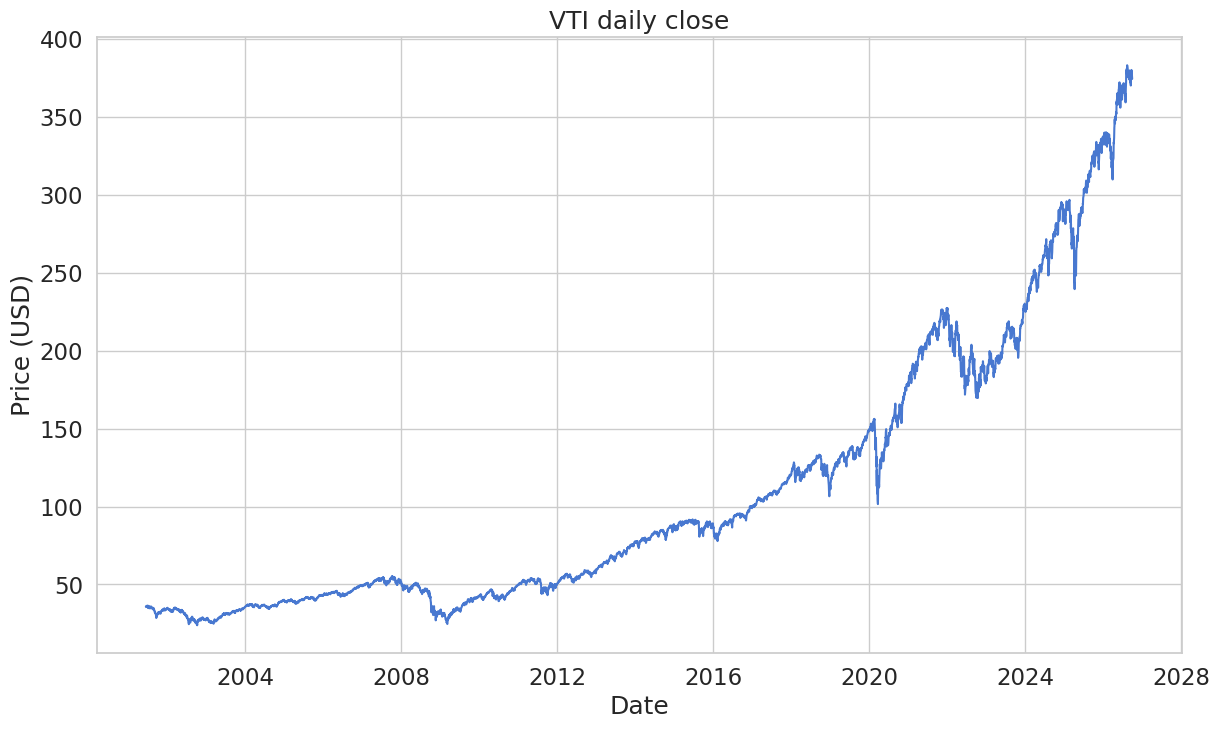

In [6]:
plt.plot(df.index, df["Close"])
plt.title(f"{ticker} daily close")
plt.xlabel("Date")
plt.ylabel("Price (USD)");

## Normalization

In [7]:
scaler = MinMaxScaler()

close_price = df.Close.values.reshape(-1, 1)

scaled_close = scaler.fit_transform(close_price)

In [8]:
scaled_close.shape

(6359, 1)

In [9]:
np.isnan(scaled_close).any()

False

In [10]:
scaled_close = scaled_close[~np.isnan(scaled_close)]

In [11]:
scaled_close = scaled_close.reshape(-1, 1)

In [12]:
np.isnan(scaled_close).any()

False

## Preprocessing: 100-step sequences, 95/5 split

In [13]:
SEQ_LEN = 100

def to_sequences(data, seq_len):
    d = []

    for index in range(len(data) - seq_len):
        d.append(data[index: index + seq_len])

    return np.array(d)

def preprocess(data_raw, seq_len, train_split):

    data = to_sequences(data_raw, seq_len)

    num_train = int(train_split * data.shape[0])

    X_train = data[:num_train, :-1, :]
    y_train = data[:num_train, -1, :]

    X_test = data[num_train:, :-1, :]
    y_test = data[num_train:, -1, :]

    return X_train, y_train, X_test, y_test


X_train, y_train, X_test, y_test = preprocess(scaled_close, SEQ_LEN, train_split = 0.95)

In [14]:
X_train.shape

(5946, 99, 1)

In [15]:
X_test.shape

(313, 99, 1)

## Model: stacked bidirectional LSTM

In [16]:
DROPOUT = 0.2
WINDOW_SIZE = SEQ_LEN - 1

model = keras.Sequential()

model.add(Bidirectional(LSTM(WINDOW_SIZE, return_sequences=True),
                        input_shape=(WINDOW_SIZE, X_train.shape[-1])))
model.add(Dropout(rate=DROPOUT))

model.add(Bidirectional(LSTM((WINDOW_SIZE * 2), return_sequences=True)))
model.add(Dropout(rate=DROPOUT))

model.add(Bidirectional(LSTM(WINDOW_SIZE, return_sequences=False)))

model.add(Dense(units=1))

model.add(Activation('linear'))

## Training

In [17]:
model.compile(
    loss='mean_squared_error', 
    optimizer='adam'
)

In [18]:
BATCH_SIZE = 64

history = model.fit(
    X_train, 
    y_train, 
    epochs=50, 
    batch_size=BATCH_SIZE, 
    shuffle=False,
    validation_split=0.1
)

Epoch 1/50


 1/84 [..............................] - ETA: 12:08 - loss: 9.2523e-04

 2/84 [..............................] - ETA: 35s - loss: 9.0750e-04  

 3/84 [>.............................] - ETA: 34s - loss: 7.7349e-04

 4/84 [>.............................] - ETA: 33s - loss: 5.8311e-04

...

81/84 [===========================>..] - ETA: 1s - loss: 2.8125e-04

82/84 [============================>.] - ETA: 0s - loss: 3.1657e-04

83/84 [============================>.] - ETA: 0s - loss: 3.7824e-04

84/84 [==============================] - ETA: 0s - loss: 4.0453e-04

84/84 [==============================] - 39s 462ms/step - loss: 4.0453e-04 - val_loss: 0.0067


In [19]:
model.evaluate(X_test, y_test)

 1/10 [==>...........................] - ETA: 0s - loss: 0.0327

 2/10 [=====>........................] - ETA: 0s - loss: 0.0382

 3/10 [========>.....................] - ETA: 0s - loss: 0.0440

 4/10 [===========>..................] - ETA: 0s - loss: 0.0479

 5/10 [==============>...............] - ETA: 0s - loss: 0.0520

...

 8/10 [=======================>......] - ETA: 0s - loss: 0.0651

 9/10 [==========================>...] - ETA: 0s - loss: 0.0722

10/10 [==============================] - ETA: 0s - loss: 0.0772

10/10 [==============================] - 1s 83ms/step - loss: 0.0772


0.07721805572509766

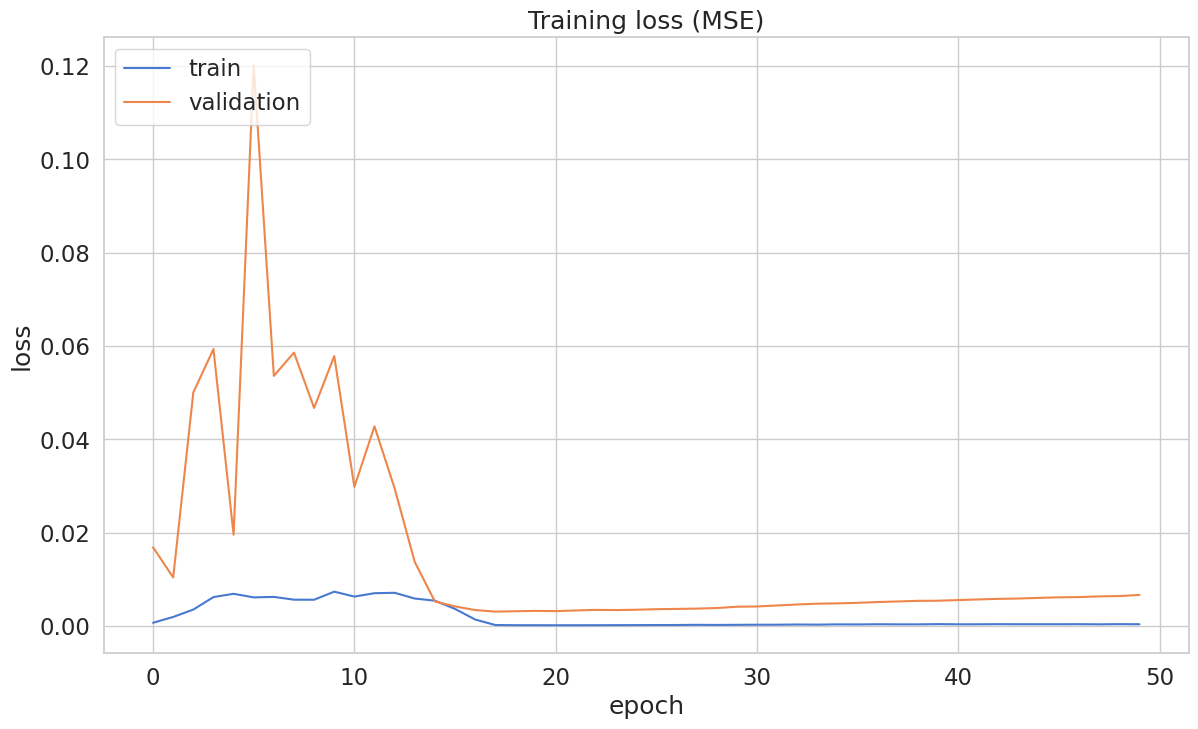

In [20]:
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.title('Training loss (MSE)')
plt.ylabel('loss')
plt.xlabel('epoch')
plt.legend(['train', 'validation'], loc='upper left')
plt.show()

## Prediction vs actual

 1/10 [==>...........................] - ETA: 16s

 2/10 [=====>........................] - ETA: 0s 

 3/10 [========>.....................] - ETA: 0s

 4/10 [===========>..................] - ETA: 0s

 5/10 [==============>...............] - ETA: 0s

...

 7/10 [====================>.........] - ETA: 0s

 8/10 [=======================>......] - ETA: 0s

 9/10 [==========================>...] - ETA: 0s

10/10 [==============================] - ETA: 0s

10/10 [==============================] - 3s 95ms/step


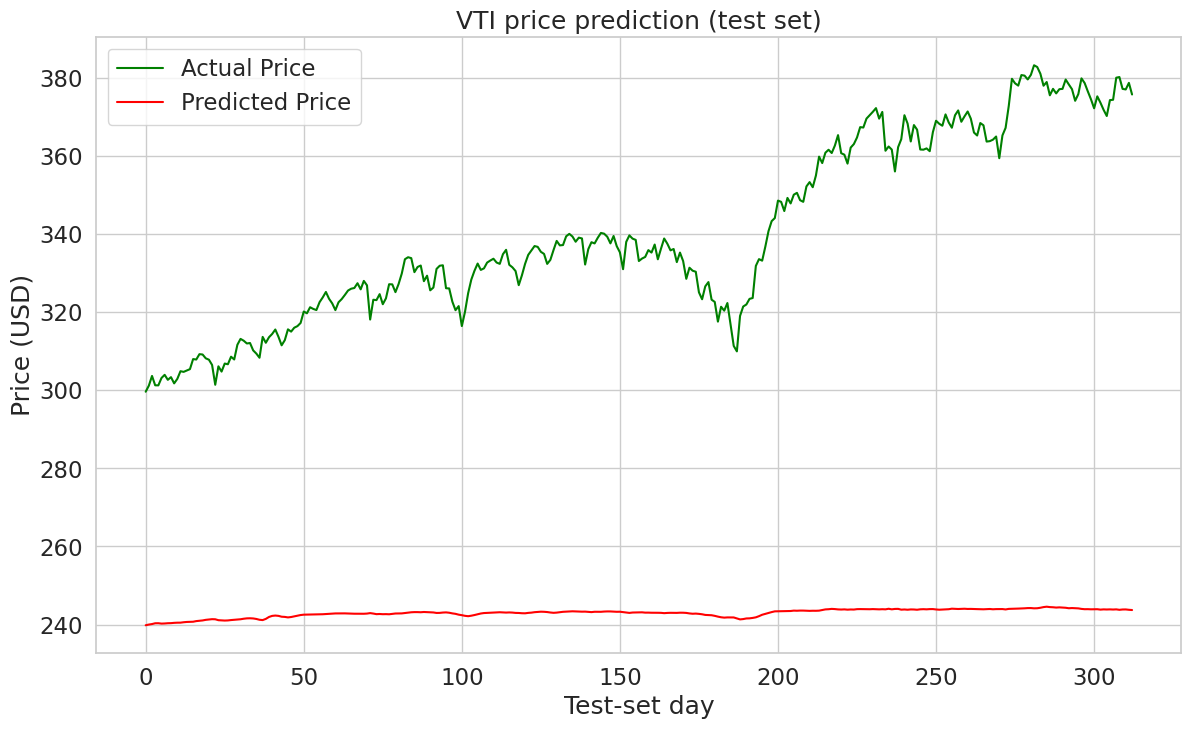

In [21]:
y_hat = model.predict(X_test)

y_test_inverse = scaler.inverse_transform(y_test)
y_hat_inverse = scaler.inverse_transform(y_hat)
 
plt.plot(y_test_inverse, label="Actual Price", color='green')
plt.plot(y_hat_inverse, label="Predicted Price", color='red')
 
plt.title(ticker+' price prediction (test set)')
plt.xlabel('Test-set day')
plt.ylabel('Price (USD)')
plt.legend(loc='best')
 
plt.show();